In [7]:
import surfradpy.database as srfdb

# Setting

In [1]:
prefix = '/Volumes'
version = '0.1' #this is wehere the langleys go
version_in = '0.2'
"""
changes
-------
0.1 - as PMOD-FRC 2025
"""

'\nchanges\n-------\n0.1 - as PMOD-FRC 2025\n'

In [2]:
site = 'inl'

In [3]:
p2ft = pl.Path('/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosine_corrected/v0.2/2026/inl_mfrsr_cosinecorrected_20260415.nc')

In [4]:
p2f_in = f'{prefix}/grad/Inst/MFR/SURFRAD/{site}/mfrsr/cosine_corrected/v{version_in}/'
# output is no longer neaded if we save parameters in database
# p2fld_lang = f'{prefix}/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.langleys/v{version}'


# Make workplan

* database workplan!
* check if next day is needed, is there afunction for that these days?

In [5]:
import productomator.worker as prowo

In [39]:
lambda p2ft: pd.to_datetime(p2ft.name.split('_')[-1].strip('.nc'))

<function __main__.<lambda>(p2ft)>

In [10]:
wp = prowo.Workplanner(
    p2fld_in = p2f_in,
    p2fld_out=None,
    database=(srfdb.get_default_db_path(), 'mfrsr_calibration_parameters', 'timestamp', 'input_file'),
    date_from_name=lambda name: pd.to_datetime(name.split('_')[-1].strip('.nc')),
    output_file_format=None,
    glob_pattern_in='*.nc',
    start=None,
    end=None,
    input_directory_structure='yearly',
    output_directory_structure=None,
    file_complete_check=False,
    reporter=None,
    verbose=True,
    # **kwargs,
)

start time: 2026-07-23 15:30:22.769674


In [30]:
self = wp

In [11]:
wp.masterplan

Get all files in /Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosine_corrected/v0.2 with glob pattern: *.nc


,p2f_in,in_database
2026-04-15,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-04-16,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-04-17,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-04-18,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-04-19,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
...,...,...
2026-07-19,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-07-20,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-07-21,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None
2026-07-22,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...,None


In [12]:
wp.workplan

,p2f_in
2026-04-15,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...
2026-04-16,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...
2026-04-17,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...
2026-04-18,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...
2026-04-19,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...
...,...
2026-07-19,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...
2026-07-20,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...
2026-07-21,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...
2026-07-22,/Volumes/grad/Inst/MFR/SURFRAD/inl/mfrsr/cosin...


In [13]:
row = wp.workplan.iloc[0] 

In [20]:
def open_p2f_in(row):
    ds = xr.open_dataset(row.p2f_in)
    return ds

In [24]:
 #######
## Open input files
#######


In [25]:
out = {}
ds = dsorig.copy()

In [27]:
ds

<xarray.Dataset> Size: 926kB
Dimensions:                     (datetime: 4288, channel: 6)
Coordinates:
  * datetime                    (datetime) datetime64[ns] 34kB 2026-04-15 ......
  * channel                     (channel) int64 48B 415 500 670 870 940 1625
Data variables:
    global_horizontal           (datetime, channel) float64 206kB ...
    direct_normal               (datetime, channel) float64 206kB ...
    diffuse_horizontal          (datetime, channel) float64 206kB ...
    channel_wavelength          (channel) float64 48B ...
    cosine_calibraion_direct    (datetime, channel) float64 206kB ...
    cosine_calibration_diffuse  (channel) float64 48B ...
    solar_zenith_angle          (datetime) float64 34kB ...
    solar_azimuth_angle         (datetime) float64 34kB ...
Attributes: (12/27)
    instrument:                 mfrsr
    start_time:                 2026-04-14 22:09:40
    avg_period:                 20
    sample_rate:                20
    logger_id:                  $BF4F
    head_id:                    $97A4
    ...                         ...
    calibrated_spectral:        True
    clalibration_cosine:        True
    processing_class:           surfradpy.products.mfrsr_cosinecorrection.Cal...
    calibration_file_cosine:    /nfs/grad/Calibration_facilities/cucf/NOAA_GR...
    calibration_file_spectral:  /nfs/grad/Calibration_facilities/cucf/NOAA_GR...
    version:                    0.2

In [28]:
# do we have all attrs?
ds

<xarray.Dataset> Size: 926kB
Dimensions:                     (datetime: 4288, channel: 6)
Coordinates:
  * datetime                    (datetime) datetime64[ns] 34kB 2026-04-15 ......
  * channel                     (channel) int64 48B 415 500 670 870 940 1625
Data variables:
    global_horizontal           (datetime, channel) float64 206kB ...
    direct_normal               (datetime, channel) float64 206kB ...
    diffuse_horizontal          (datetime, channel) float64 206kB ...
    channel_wavelength          (channel) float64 48B ...
    cosine_calibraion_direct    (datetime, channel) float64 206kB ...
    cosine_calibration_diffuse  (channel) float64 48B ...
    solar_zenith_angle          (datetime) float64 34kB ...
    solar_azimuth_angle         (datetime) float64 34kB ...
Attributes: (12/27)
    instrument:                 mfrsr
    start_time:                 2026-04-14 22:09:40
    avg_period:                 20
    sample_rate:                20
    logger_id:                  $BF4F
    head_id:                    $97A4
    ...                         ...
    calibrated_spectral:        True
    clalibration_cosine:        True
    processing_class:           surfradpy.products.mfrsr_cosinecorrection.Cal...
    calibration_file_cosine:    /nfs/grad/Calibration_facilities/cucf/NOAA_GR...
    calibration_file_spectral:  /nfs/grad/Calibration_facilities/cucf/NOAA_GR...
    version:                    0.2

In [29]:
# rename vars?

In [53]:
ds.site_latitude

np.float64(43.594919)

In [54]:
ds.site_longitude

np.float64(-112.928561)

In [44]:
def open_local_day(row):
    """opens this and the next days file if needed. Also cuts of previous and next day"""
    # next one needed?
    out = {}
    ds = open_p2f_in(row)
    sunup_start = ds.solar_zenith_angle.isel(datetime = 0) < 90 #still in the sky in beginning of file
    sunup_end = ds.solar_zenith_angle.isel(datetime = -1) < 90 #still in the sky at end of file
    # sunrising_end = ds.solar_elevation.differentiate('time').isel(time = -1) > 0 #sun is rising at the end
    next_day_needed = False
    dslist = []
    if sunup_start:
    # delete everything before first solar_elevation minimum
        dslist.append(ds.sel(datetime = slice(ds.solar_zenith_angle.idxmax(), None)))
    else:
        dslist.append(ds)
    
    if sunup_end:
        try:
            row_next = self.masterplan.iloc[self.masterplan.index.get_loc(row.name)+1]
        except IndexError:
            print('We have to wait for the next day to to finish this local day.')
            # assert(False)
            out['status'] = "Day not done yet"
            return out
        
        next_day_needed = True
    
        dsnext = open_p2f_in(row_next)
        dsnext = dsnext.sel(datetime = slice(None,dsnext.solar_zenith_angle.idxmax()))
        dslist.append(dsnext)
        self.tp_dsnext = dsnext.copy()
    
    ds_wholeday = xr.concat(dslist, dim = 'datetime')
    ds_wholeday = ds_wholeday.where(ds_wholeday.solar_zenith_angle < 90, drop = True)
    out['status'] = ['valid']
    out['dataset']= ds_wholeday
    return out

In [45]:
out = open_local_day(row)

/var/folders/f4/dl3whmyd1rj_9smbyhmyqyj1h26f40/T/ipykernel_41521/868716427.py:33: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_wholeday = xr.concat(dslist, dim = 'datetime')


In [46]:
ds = out['dataset']

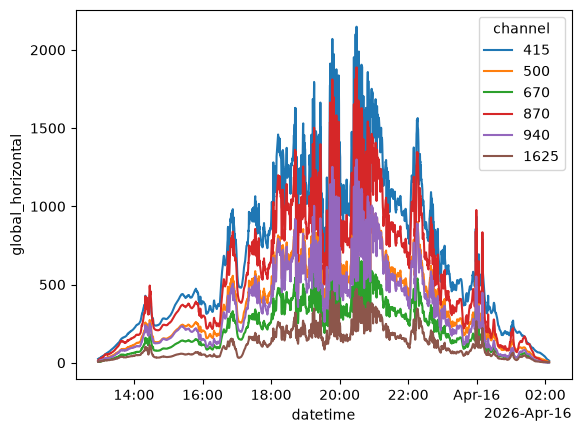

In [47]:
ds.global_horizontal.plot.line(x = 'datetime')

In [48]:
import atmPy.radiation.retrievals.spectral_irradiance as atmspec

In [ ]:
out = {}

In [49]:
si = atmspec.CombinedGlobalDiffuseDirect(ds.copy())

In [51]:
sir = si.direct_normal_irradiation

In [52]:
langley_airmass_limits = (2.5, 5)
sir.settings_langley_airmass_limits = langley_airmass_limits

# NEXT: continue the above (helper function line ~ 216)

# Get the right pwd lookuptable

In [ ]:
fnlut = f'/Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_{serialno}.nc'
p2fld_lang, fnlut

# Some databank stuff, might not be needed later?

In [45]:
import surfradpy.database as srfdb

In [54]:
reload(srfdb)

<module 'surfradpy.database' from '/Users/htelg/prog/SURFRAD/surfradpy/database.py'>

In [55]:
srfdb.get_default_db_path()

PosixPath('/Users/htelg/prog/SURFRAD/notebooks/databases/surfrad_database.db')

In [56]:
db = srfdb.SurfradDatabase(srfdb.get_default_db_path())

In [57]:
columns = ['id', 'lang_version','site', 'date', 'path2file', 'channel','V0']

In [58]:
db.add_table(tbl_name="mfrsr_calibration_parameters", columns=columns)

In [ ]:
db.